# Gradient Boosting from First Principles
### Least-Squares Regression Setting

This notebook walks through gradient boosting *manually* — no black-box libraries, just
NumPy trees and math — so every step is visible. We follow the derivation exactly:

$$F_{m+1}(x_i) = F_m(x_i) + h_m(x_i)$$

where each $h_m$ is a shallow decision tree fit to the **residuals** $y_i - F_m(x_i)$,
which (as we'll prove) are proportional to the **negative gradient** of the MSE loss.


## 0 · Imports & reproducibility

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(42)

# ── plot style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.color":       "white",
    "grid.linewidth":   1.2,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})
COLORS = dict(truth="#2d6a9f", pred="#e05c2a", resid="#2a9e5c", tree="#9b59b6")
print("Imports OK ✓")


Imports OK ✓


## 1 · Toy Dataset

We generate a noisy sine curve — smooth enough to be predictable, wiggly enough to
need multiple trees.  
$y = 2\sin(x) + \varepsilon,\quad \varepsilon \sim \mathcal{N}(0, 0.4)$


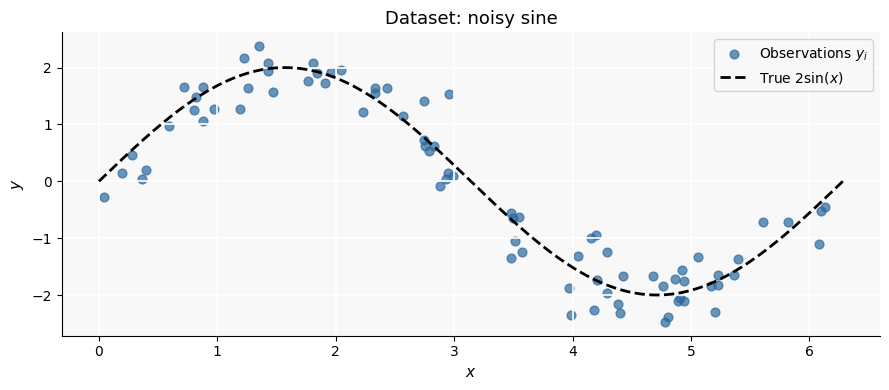

In [23]:
n = 80
X = rng.uniform(0, 2 * np.pi, n).reshape(-1, 1)
y = 2 * np.sin(X.ravel()) + rng.normal(0, 0.4, n)

x_plot = np.linspace(0, 2 * np.pi, 300).reshape(-1, 1)
y_true = 2 * np.sin(x_plot.ravel())

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(X, y, alpha=0.7, s=40, color=COLORS["truth"], label=r"Observations $y_i$")
ax.plot(x_plot, y_true, lw=2, color="black", ls="--", label=r"True $2\sin(x)$")
ax.set_title("Dataset: noisy sine")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.legend()
plt.tight_layout()
plt.show()


## 2 · The Gradient Connection (the "why")

Our loss is the mean squared error:

$$\mathcal{L}_{\text{MSE}} = \frac{1}{n}\sum_{i=1}^n \bigl(y_i - F(x_i)\bigr)^2$$

Taking the partial derivative w.r.t. the **prediction** $F(x_i)$:

$$\frac{\partial \mathcal{L}}{\partial F(x_i)}
    = \frac{2}{n}\bigl(F(x_i) - y_i\bigr)$$

The **negative gradient** is therefore:

$$-\frac{\partial \mathcal{L}}{\partial F(x_i)}
    = \frac{2}{n}\bigl(y_i - F(x_i)\bigr)
    = \frac{2}{n} \cdot h_m(x_i)$$

> **Key insight:** the residual $h_m(x_i) = y_i - F_m(x_i)$ is proportional to the
> negative gradient of MSE.  Fitting each tree to the residuals *is* gradient descent
> in function space.


## 3 · Manual Gradient Boosting Loop

We implement the algorithm from scratch:

| Symbol | Meaning |
|--------|---------|
| $F_0$ | Initial prediction = $\bar{y}$ |
| $r_m$ | Residuals at stage $m$ |
| $h_m$ | Shallow tree fit to $r_m$ |
| $\eta$ | Learning rate (shrinkage) |
| $F_{m+1}$ | Updated ensemble |


In [24]:
M          = 10      # number of boosting rounds
eta        = 0.4     # learning rate
max_depth  = 2       # tree depth (weak learner)

# ── Initialise: predict the mean ──────────────────────────────────────────────
F   = np.full(n, y.mean())          # current predictions on training set
F_p = np.full(300, y.mean())        # current predictions on plot grid

history = []    # we'll store snapshots for visualisation

for m in range(1, M + 1):
    # Step 1 · compute residuals  (= negative MSE gradient, up to 2/n)
    residuals = y - F

    # Step 2 · fit a shallow tree to the residuals
    tree = DecisionTreeRegressor(max_depth=max_depth)
    tree.fit(X, residuals)

    # Step 3 · update the ensemble
    F   = F   + eta * tree.predict(X)
    F_p = F_p + eta * tree.predict(x_plot)

    mse = mean_squared_error(y, F)
    history.append({
        "round":     m,
        "residuals": residuals.copy(),
        "F":         F.copy(),
        "F_p":       F_p.copy(),
        "mse":       mse,
        "tree":      tree,
    })
    print(f"Round {m:2d}  |  MSE = {mse:.4f}")


Round  1  |  MSE = 1.0122
Round  2  |  MSE = 0.4967
Round  3  |  MSE = 0.2876
Round  4  |  MSE = 0.1935
Round  5  |  MSE = 0.1503
Round  6  |  MSE = 0.1269
Round  7  |  MSE = 0.1107
Round  8  |  MSE = 0.1026
Round  9  |  MSE = 0.0958
Round 10  |  MSE = 0.0915


## 4 · Step-by-Step Visualisation

For rounds 1, 2, 3, 5, and 10 we show:
- **Left**: ensemble prediction vs truth
- **Right**: residuals (what the next tree will target)


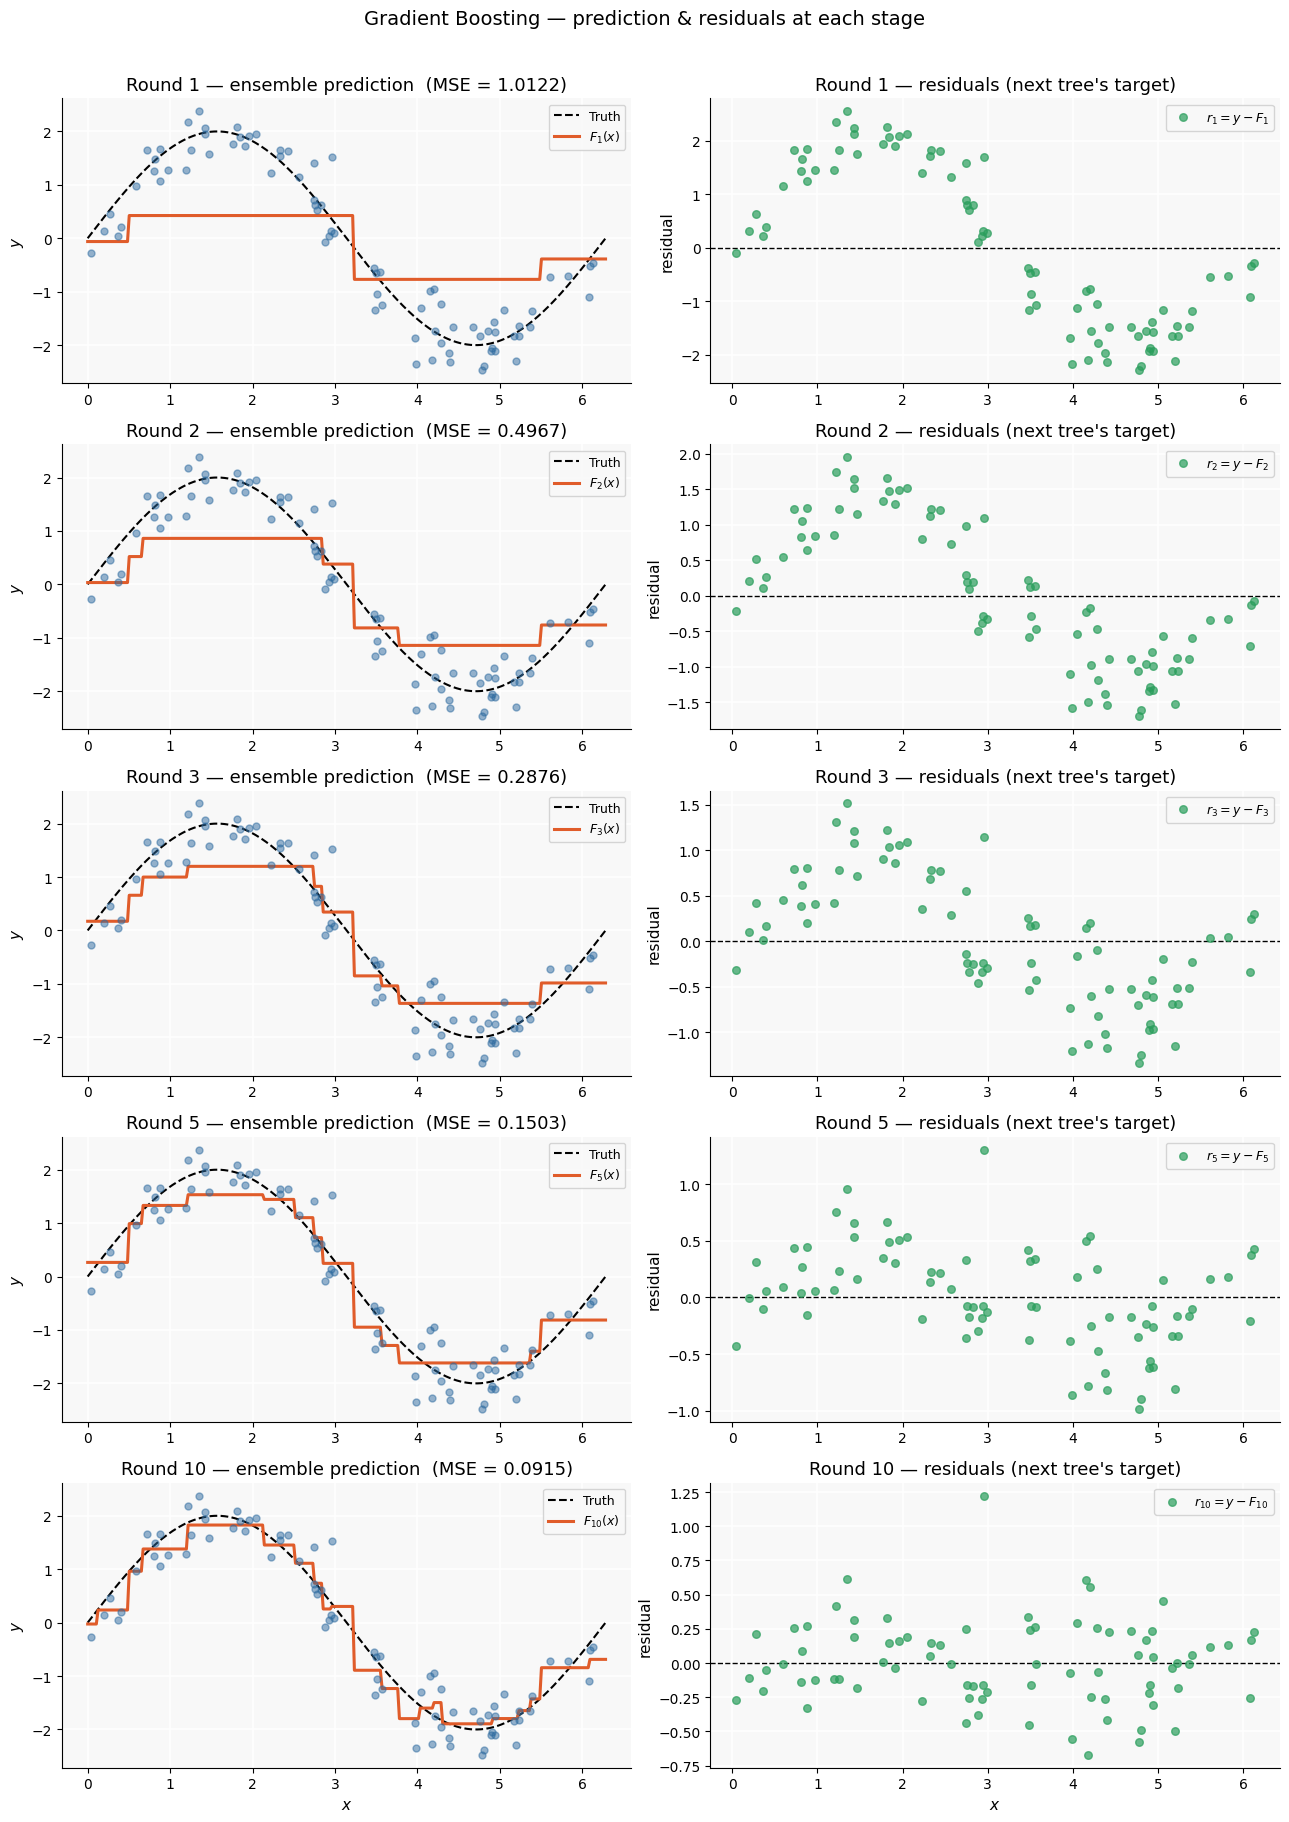

In [25]:
show_rounds = [1, 2, 3, 5, 10]

fig, axes = plt.subplots(len(show_rounds), 2,
                         figsize=(13, 3.6 * len(show_rounds)))

for row, m in enumerate(show_rounds):
    snap = history[m - 1]
    ax_pred, ax_res = axes[row]

    # ── left: prediction ──────────────────────────────────────────────────────
    ax_pred.scatter(X, y, alpha=0.5, s=25, color=COLORS["truth"], zorder=3)
    ax_pred.plot(x_plot, y_true,  lw=1.5, color="black",         ls="--", label="Truth")
    ax_pred.plot(x_plot, snap["F_p"], lw=2.2, color=COLORS["pred"], label=f"$F_{{{m}}}(x)$")
    ax_pred.set_title(f"Round {m} — ensemble prediction  (MSE = {snap['mse']:.4f})")
    ax_pred.set_ylabel("$y$"); ax_pred.legend(fontsize=9)

    # ── right: residuals ──────────────────────────────────────────────────────
    ax_res.axhline(0, color="black", lw=1, ls="--")
    ax_res.scatter(X, snap["residuals"], alpha=0.7, s=30,
                   color=COLORS["resid"], zorder=3, label=f"$r_{{{m}}} = y - F_{{{m}}}$")
    ax_res.set_title(f"Round {m} — residuals (next tree's target)")
    ax_res.set_ylabel("residual"); ax_res.legend(fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("$x$")

plt.suptitle("Gradient Boosting — prediction & residuals at each stage",
             fontsize=14, y=1.01)
plt.tight_layout(); plt.show()


## 5 · MSE Learning Curve

Each boosting round reduces the training MSE. The curve flattens as residuals shrink —
adding more trees gives diminishing returns (and risks overfitting without regularisation).


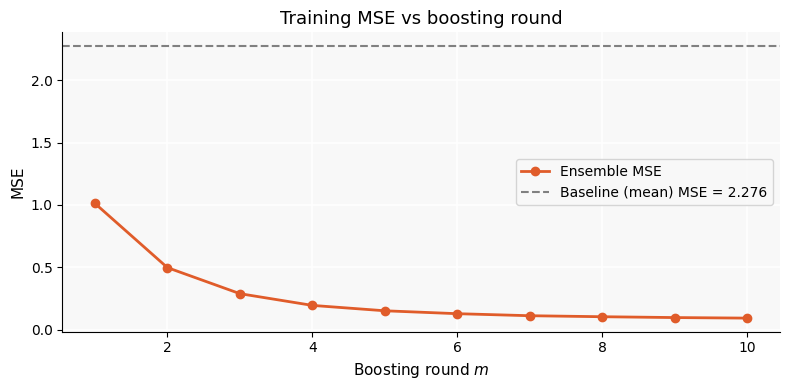

In [26]:
rounds = [h["round"] for h in history]
mses   = [h["mse"]   for h in history]
baseline_mse = mean_squared_error(y, np.full(n, y.mean()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rounds, mses, "o-", color=COLORS["pred"], lw=2, ms=6, label="Ensemble MSE")
ax.axhline(baseline_mse, color="grey", ls="--", lw=1.5, label=f"Baseline (mean) MSE = {baseline_mse:.3f}")
ax.set_xlabel("Boosting round $m$")
ax.set_ylabel("MSE")
ax.set_title("Training MSE vs boosting round")
ax.legend(); plt.tight_layout(); plt.show()


## 6 · Visualising the Gradient Descent Analogy

Each tree moves the prediction vector **$\mathbf{F}$** in the direction of steepest
descent on the MSE loss surface.  Here we project onto two dimensions using PCA to
illustrate the trajectory.


<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
/var/folders/3w/nf3t5ncs1w7cnxw9_g7ckl2h0000gn/T/ipykernel_26264/2945877159.py:30: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(x_plot, c, alpha=0.75, lw=1.5, label=f"$\eta \cdot h_{{{i}}}$")


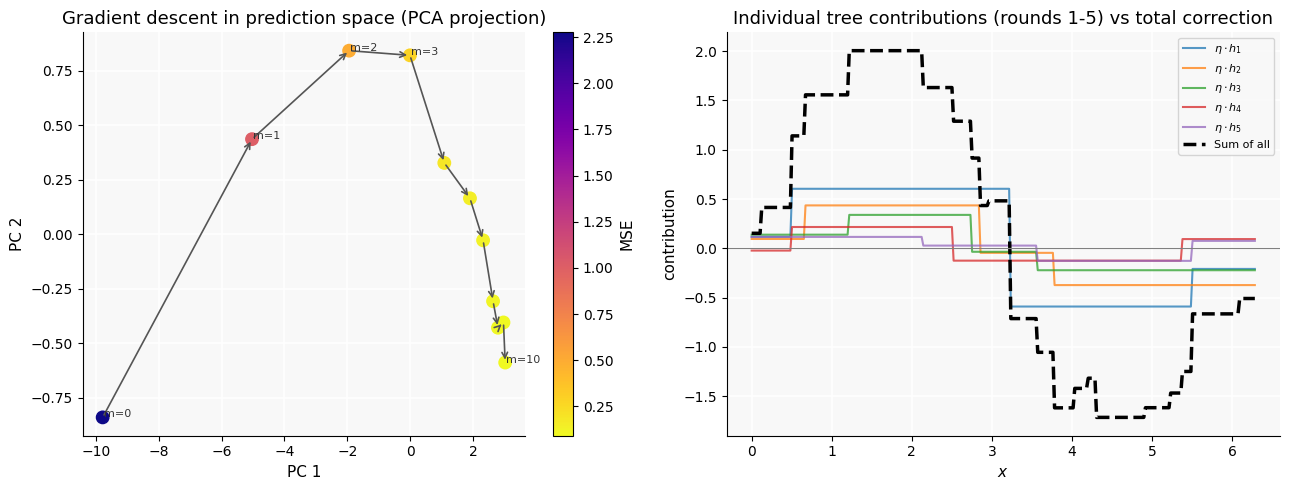

In [27]:
from sklearn.decomposition import PCA

# collect all training-set prediction vectors
F_seq = np.array([np.full(n, y.mean())] + [h["F"] for h in history])

pca   = PCA(n_components=2)
F_2d  = pca.fit_transform(F_seq)
loss_seq = [mean_squared_error(y, f) for f in F_seq]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: PCA trajectory ──────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(F_2d[:, 0], F_2d[:, 1], c=loss_seq,
                cmap="plasma_r", s=80, zorder=3)
for i in range(len(F_2d) - 1):
    ax.annotate("", xy=F_2d[i+1], xytext=F_2d[i],
                arrowprops=dict(arrowstyle="->", color="#555", lw=1.2))
for i, (pt, mse) in enumerate(zip(F_2d, loss_seq)):
    ax.text(pt[0]+0.04, pt[1], f"m={i}" if i < 4 or i == M else "",
            fontsize=8, color="#333")
plt.colorbar(sc, ax=ax, label="MSE")
ax.set_title("Gradient descent in prediction space (PCA projection)")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")

# ── right: contribution of each tree ─────────────────────────────────────────
ax2 = axes[1]
contribs = [eta * h["tree"].predict(x_plot) for h in history]
for i, c in enumerate(contribs[:5], start=1):
    ax2.plot(x_plot, c, alpha=0.75, lw=1.5, label=f"$\eta \cdot h_{{{i}}}$")
ax2.plot(x_plot, history[-1]["F_p"] - np.full(300, y.mean()),
         lw=2.5, color="black", ls="--", label="Sum of all")
ax2.axhline(0, color="grey", lw=0.8)
ax2.set_title("Individual tree contributions (rounds 1-5) vs total correction")
ax2.set_xlabel("$x$"); ax2.set_ylabel("contribution")
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()


## 7 · Effect of the Learning Rate $\eta$

A high $\eta$ converges fast but can overshoot; a low $\eta$ needs more trees.
This is the **shrinkage** regularisation in XGBoost.


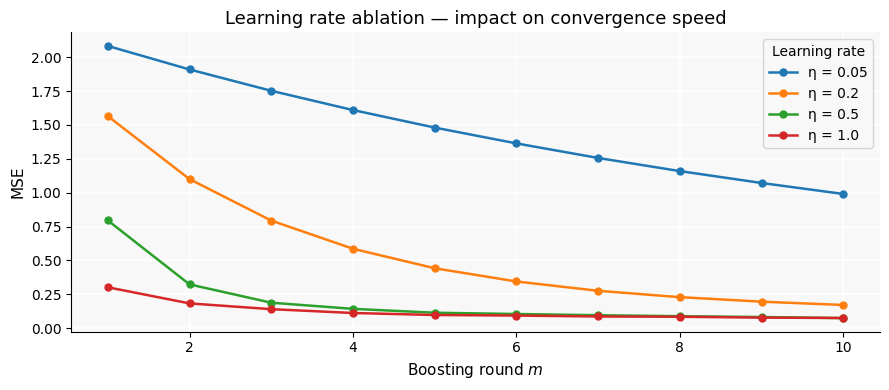

In [28]:
etas  = [0.05, 0.2, 0.5, 1.0]
fig, ax = plt.subplots(figsize=(9, 4))

for eta_test in etas:
    F_test = np.full(n, y.mean())
    mse_curve = []
    for _ in range(M):
        r = y - F_test
        t = DecisionTreeRegressor(max_depth=2)
        t.fit(X, r)
        F_test += eta_test * t.predict(X)
        mse_curve.append(mean_squared_error(y, F_test))
    ax.plot(range(1, M+1), mse_curve, "o-", lw=1.8, ms=5, label=f"η = {eta_test}")

ax.set_xlabel("Boosting round $m$")
ax.set_ylabel("MSE")
ax.set_title("Learning rate ablation — impact on convergence speed")
ax.legend(title="Learning rate")
plt.tight_layout(); plt.show()


## 8 · Summary

| Concept | Gradient-boosting interpretation |
|---------|----------------------------------|
| $F_0 = \bar{y}$ | Start at the "laziest" prediction |
| Residual $r_m = y - F_m$ | Negative gradient of MSE (up to $2/n$) |
| Fit $h_m$ to $r_m$ | Move in the steepest-descent direction |
| $F_{m+1} = F_m + \eta h_m$ | Gradient-descent update in function space |
| Small $\eta$ | Shrinkage — regularisation against overfitting |
| Shallow trees | Weak learners → ensemble beats any single tree |

**The generalisation step** (XGBoost): replace MSE with any differentiable loss
$\mathcal{L}(y, F)$ and fit each $h_m$ to
$-\frac{\partial \mathcal{L}}{\partial F(x_i)}$.
XGBoost further adds the *second-order* (Hessian) term for more accurate leaf values
and L1/L2 regularisation on tree structure.

---

> **Try it yourself:** change `M`, `eta`, `max_depth`, or swap the sine for a different
> function and re-run — the core maths stays identical.
